In [8]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import pandas as pd
import numpy as np

In [2]:
# ==========================
# (NVDA) NVIDIA - King
# (META) META - AI + Advertising + Metaverse play
# (AVGO) Broadcom - AI chips + semiconductor + VMware
# (LLY) Eli Lilly - GLP-1 (Ozempic competitor) + pharma-AI
# (ASML) ASML Holding - EUV lithography monopoly

tickers = ['NVDA', 'META', 'AVGO', 'LLY', 'ASML']
waktu_berakhir = datetime.now()
waktu_mulai = waktu_berakhir - timedelta(days=5*365)

data_saham = pd.DataFrame()

for ticker in tickers:
    try:
        # Download data for a single ticker
        data = yf.download(ticker, start=waktu_mulai, end=waktu_berakhir, progress=False) # progress=False to reduce output
        if not data.empty:
            if 'Adj Close' in data.columns:
                data_saham[ticker] = data['Adj Close']
            elif 'Close' in data.columns:
                # Fallback to 'Close' price if 'Adj Close' is not available (e.g., if auto_adjust makes them identical)
                data_saham[ticker] = data['Close']
                print(f"Warning: 'Adj Close' not found for {ticker}, using 'Close' price.")
            else:
                print(f"Could not find 'Adj Close' or 'Close' data for {ticker}.")
        else:
            print(f"No data downloaded for {ticker}.")
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")

C:\Users\natsuka-fr\AppData\Local\Temp\ipykernel_6960\2606053306.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=waktu_mulai, end=waktu_berakhir, progress=False) # progress=False to reduce output


C:\Users\natsuka-fr\AppData\Local\Temp\ipykernel_6960\2606053306.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=waktu_mulai, end=waktu_berakhir, progress=False) # progress=False to reduce output


C:\Users\natsuka-fr\AppData\Local\Temp\ipykernel_6960\2606053306.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=waktu_mulai, end=waktu_berakhir, progress=False) # progress=False to reduce output


C:\Users\natsuka-fr\AppData\Local\Temp\ipykernel_6960\2606053306.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=waktu_mulai, end=waktu_berakhir, progress=False) # progress=False to reduce output


C:\Users\natsuka-fr\AppData\Local\Temp\ipykernel_6960\2606053306.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=waktu_mulai, end=waktu_berakhir, progress=False) # progress=False to reduce output


In [3]:
# Drop any rows with missing values that might occur if some dates are not present for all stocks
data_saham.dropna(inplace=True)

# Tampilkan lima baris pertama dari DataFrame
print("\nData harga saham historis (Close) untuk 5 saham:")
print(data_saham.head())

print("\nInformasi DataFrame:\n")
data_saham.info()


Data harga saham historis (Close) untuk 5 saham:
                 NVDA        META       AVGO         LLY        ASML
Date                                                                
2020-12-04  13.520983  277.986298  36.792400  140.875900  443.909668
2020-12-07  13.569345  283.830292  37.615509  139.898453  449.014130
2020-12-08  13.313304  281.663605  37.840733  141.682556  447.905334
2020-12-09  12.895205  276.217224  37.198151  149.938675  432.916809
2020-12-10  12.936592  275.422089  36.645832  152.785583  437.610229

Informasi DataFrame:

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1253 entries, 2020-12-04 to 2025-12-01
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NVDA    1253 non-null   float64
 1   META    1253 non-null   float64
 2   AVGO    1253 non-null   float64
 3   LLY     1253 non-null   float64
 4   ASML    1253 non-null   float64
dtypes: float64(5)
memory usage: 58.7 KB


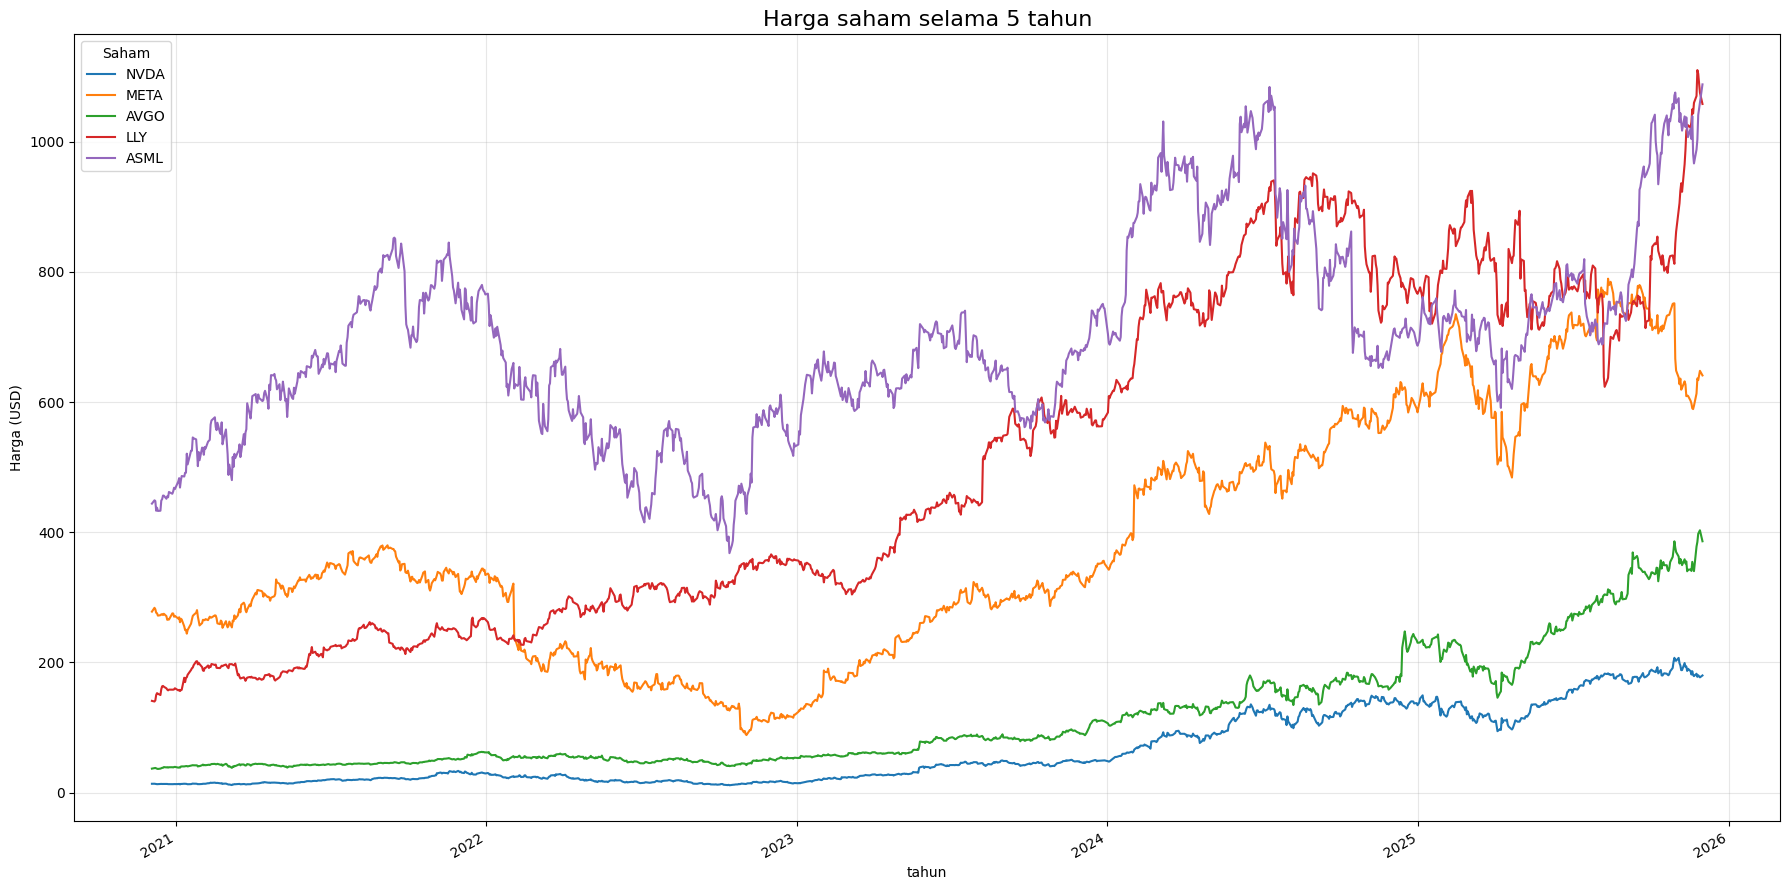

In [4]:
# Plot
plt.figure(figsize=(18, 9))
data_saham.plot(ax=plt.gca())
plt.title('Harga saham selama 5 tahun', fontsize=16)
plt.xlabel('tahun')
plt.ylabel('Harga (USD)')
plt.legend(title='Saham')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# ===========================================================
print("\nInformasi Ringkas DataFrame data_saham:")
data_saham.info()

print("\nStatistik Deskriptif DataFrame data_saham:")
print(data_saham.describe())

print("\nJumlah Nilai Hilang per Kolom di data_saham:")
print(data_saham.isnull().sum())


Informasi Ringkas DataFrame data_saham:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1253 entries, 2020-12-04 to 2025-12-01
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NVDA    1253 non-null   float64
 1   META    1253 non-null   float64
 2   AVGO    1253 non-null   float64
 3   LLY     1253 non-null   float64
 4   ASML    1253 non-null   float64
dtypes: float64(5)
memory usage: 58.7 KB

Statistik Deskriptif DataFrame data_saham:
              NVDA         META         AVGO          LLY         ASML
count  1253.000000  1253.000000  1253.000000  1253.000000  1253.000000
mean     64.446741   380.483177   113.859705   504.941228   696.467246
std      55.879631   184.105274    87.110546   259.488811   149.842250
min      11.213528    88.365250    36.268688   139.898453   367.782654
25%      18.811821   235.577698    49.071030   265.194092   597.197937
50%      38.743969   329.588196    77.509201   430.111206   679.6

In [6]:
daily_returns = data_saham.pct_change().dropna()

# Hitung monthly returns
# Resample data to get the last trading day of each month and calculate percentage change
monthly_returns = data_saham.resample('ME').last().pct_change().dropna()

# Normalisasi data
# Divide each price by the price on the first day for each stock
normalized_stock_data = data_saham / data_saham.iloc[0]

# Tampilkan lima baris pertama dari daily_returns, monthly_returns, dan normalized_stock_data
print("\nLima Baris Pertama Daily Returns:")
print(daily_returns.head())

print("\nLima Baris Pertama Monthly Returns:")
print(monthly_returns.head())

print("\nLima Baris Pertama Normalized Stock Data:")
print(normalized_stock_data.head())


Lima Baris Pertama Daily Returns:
                NVDA      META      AVGO       LLY      ASML
Date                                                        
2020-12-07  0.003577  0.021023  0.022372 -0.006938  0.011499
2020-12-08 -0.018869 -0.007634  0.005988  0.012753 -0.002469
2020-12-09 -0.031405 -0.019336 -0.016981  0.058272 -0.033464
2020-12-10  0.003209 -0.002879 -0.014848  0.018987  0.010841
2020-12-11  0.003161 -0.012883 -0.010292 -0.005962 -0.011293

Lima Baris Pertama Monthly Returns:
                NVDA      META      AVGO       LLY      ASML
Date                                                        
2021-01-31 -0.004998 -0.054291  0.028891  0.231758  0.095219
2021-02-28  0.055794 -0.002748  0.042996 -0.010696  0.061648
2021-03-31 -0.026369  0.143273 -0.005503 -0.088194  0.088645
2021-04-30  0.124454  0.103725 -0.016089 -0.021678  0.049793
2021-05-31  0.082281  0.011228  0.035357  0.097678  0.045247

Lima Baris Pertama Normalized Stock Data:
                NVDA      META 

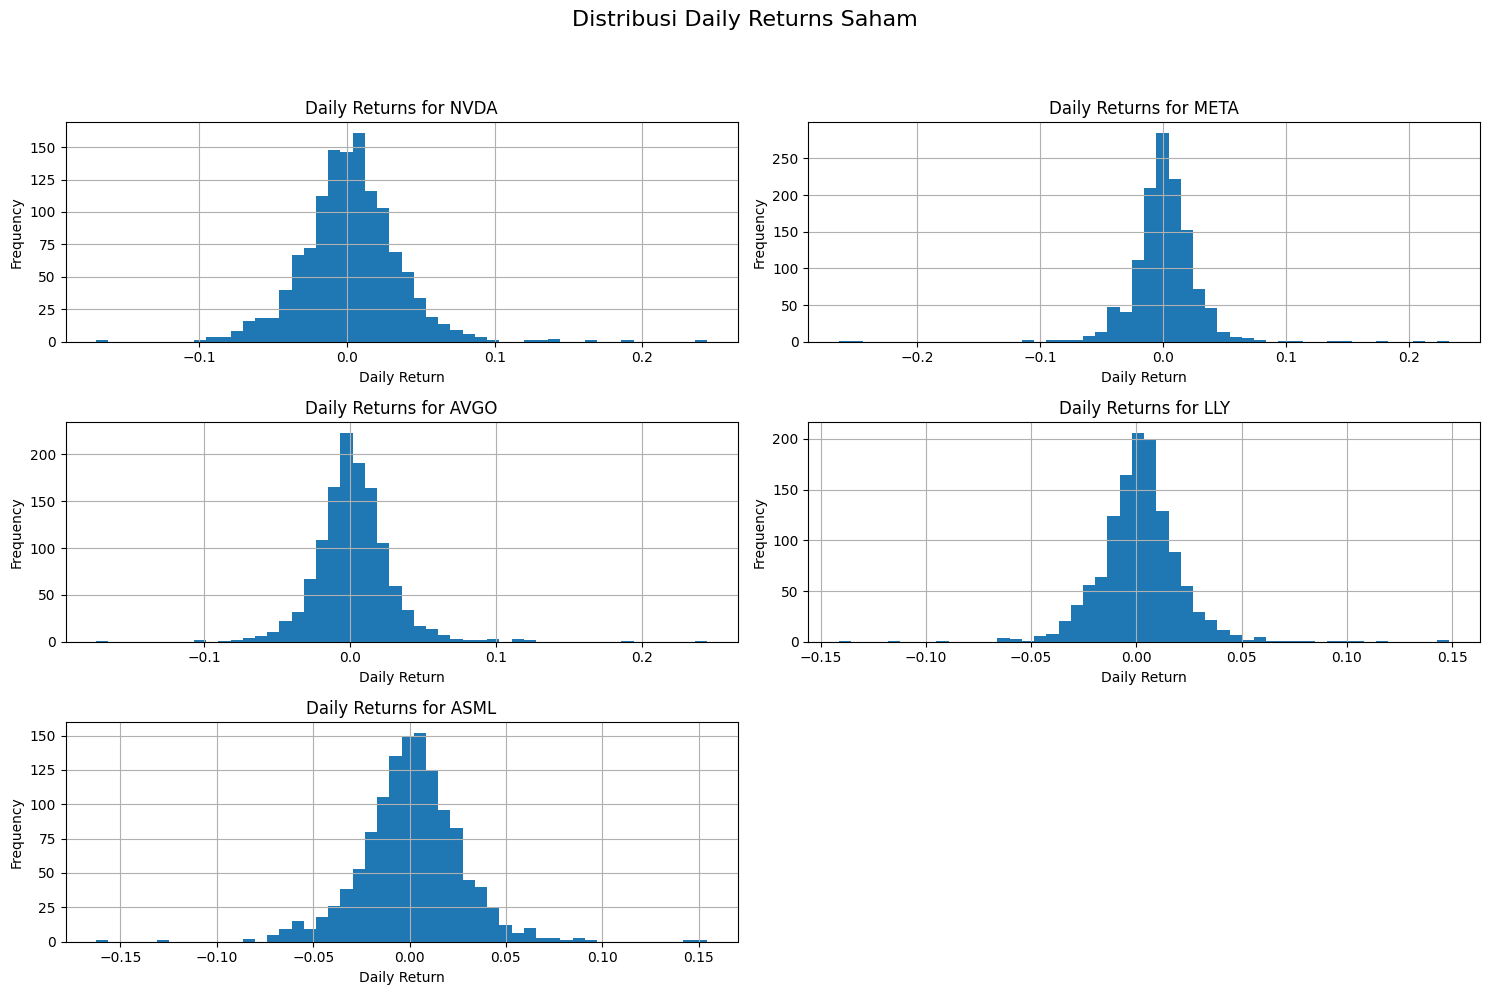

Histograms untuk daily returns telah ditampilkan.


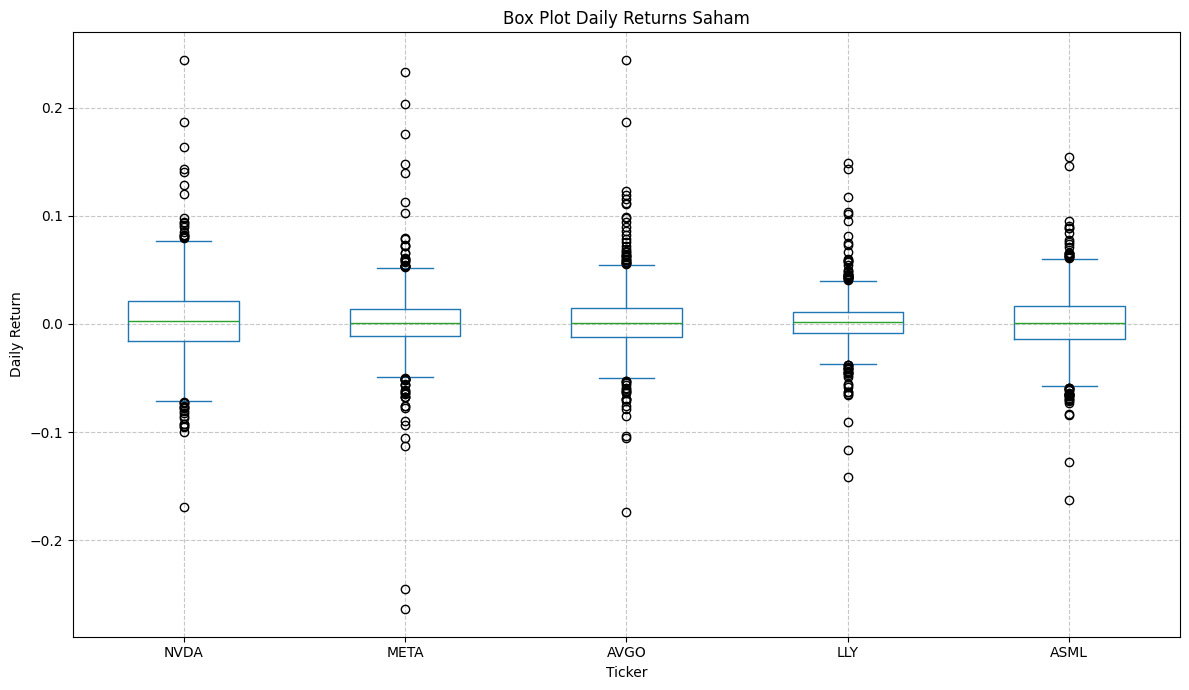

Box plots untuk daily returns telah ditampilkan.


In [9]:
hist_axes = daily_returns.hist(bins=50, figsize=(15, 10)) # Set figsize here

# Get the figure created by daily_returns.hist() to set the suptitle
fig_hist = plt.gcf()
fig_hist.suptitle('Distribusi Daily Returns Saham', y=1.02, fontsize=16)


# Flatten the axes array if it's 2D (e.g., if there are multiple rows of subplots)
if isinstance(hist_axes, (list, np.ndarray)) and len(hist_axes.shape) > 1:
    hist_axes = hist_axes.flatten()

for i, ax in enumerate(hist_axes):
    # Ensure we don't go out of bounds for daily_returns.columns (though hist() should match)
    if i < len(daily_returns.columns):
        ax.set_xlabel('Daily Return')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Daily Returns for {daily_returns.columns[i]}')

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

print("Histograms untuk daily returns telah ditampilkan.")

# Buat box plot untuk return harian
plt.figure(figsize=(12, 7))
daily_returns.plot(kind='box', ax=plt.gca())
plt.title('Box Plot Daily Returns Saham')
plt.xlabel('Ticker')
plt.ylabel('Daily Return')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Box plots untuk daily returns telah ditampilkan.")

In [11]:
import plotly_express as px

# 1. Buat line plot interaktif untuk normalized_stock_data
fig_normalized_prices = px.line(
    normalized_stock_data,
    x=normalized_stock_data.index,
    y=normalized_stock_data.columns,
    title='Perbandingan Harga Saham yang Dinormalisasi (Interaktif)',
    labels={'index': 'Tanggal', 'value': 'Harga Dinormalisasi'},
    hover_name=normalized_stock_data.columns.name # Display ticker name on hover
)

fig_normalized_prices.update_layout(
    xaxis_title='Tanggal',
    yaxis_title='Harga Dinormalisasi'
)

fig_normalized_prices.show()

print("Line plot interaktif untuk harga saham yang dinormalisasi telah ditampilkan.")

Line plot interaktif untuk harga saham yang dinormalisasi telah ditampilkan.


In [13]:
import plotly_express as px

# 2. Buat histogram interaktif untuk daily_returns

print("Membuat histogram interaktif untuk daily returns setiap saham...")

for col in daily_returns.columns:
    fig_hist_daily_returns = px.histogram(
        daily_returns,
        x=col,
        nbins=50, # Number of bins
        title=f'Distribusi Daily Returns Interaktif untuk {col}',
        labels={col: 'Daily Return', 'count': 'Frekuensi'}
    )
    fig_hist_daily_returns.update_layout(xaxis_title='Daily Return', yaxis_title='Frekuensi')
    fig_hist_daily_returns.show()

print("Histogram interaktif untuk daily returns telah ditampilkan.")

Membuat histogram interaktif untuk daily returns setiap saham...


Histogram interaktif untuk daily returns telah ditampilkan.


### Konsep Metrik Portofolio

Berikut adalah penjelasan singkat mengenai metrik-metrik yang akan kita hitung:

*   **Cumulative Return (Pengembalian Kumulatif)**:
    Pengembalian kumulatif mengukur total perubahan nilai investasi dari awal periode hingga akhir periode, tanpa memperhitungkan fluktuasi di antaranya. Ini adalah cara sederhana untuk melihat seberapa besar investasi telah tumbuh atau menyusut secara keseluruhan.
    Rumus: `(Harga Akhir / Harga Awal) - 1` atau `(1 + return_harian_1) * (1 + return_harian_2) * ... * (1 + return_harian_n) - 1`

*   **Annual Return (Pengembalian Tahunan)**:
    Pengembalian tahunan adalah tingkat pengembalian rata-rata yang diperoleh investasi dalam setahun. Ini membantu membandingkan kinerja investasi dengan jangka waktu yang berbeda secara adil. Dapat dihitung sebagai rata-rata aritmetika atau rata-rata geometris yang di-annualisasi.
    Rumus (Rata-rata Geometris): `(1 + Cumulative Return)^(1/jumlah_tahun) - 1`
    Rumus (Rata-rata Aritmetika yang di-annualisasi): `return_rata_rata_harian * jumlah_hari_perdagangan`

*   **Annualized Volatility (Volatilitas Tahunan) / Risiko**:
    Volatilitas tahunan mengukur seberapa besar fluktuasi harga suatu aset atau portofolio dalam setahun. Ini adalah indikator risiko: semakin tinggi volatilitas, semakin besar risiko yang terkait dengan aset tersebut. Dihitung sebagai standar deviasi return yang di-annualisasi.
    Rumus: `Standar Deviasi Harian Return * sqrt(jumlah_hari_perdagangan)`

*   **Sharpe Ratio (Rasio Sharpe)**:
    Rasio Sharpe adalah metrik yang digunakan untuk mengevaluasi kinerja investasi dengan memperhitungkan risikonya. Rasio ini mengukur kelebihan pengembalian (return di atas tingkat bebas risiko) per unit risiko. Semakin tinggi Rasio Sharpe, semakin baik pengembalian investasi dibandingkan dengan risiko yang diambil.
    Rumus: `(Annual Return - Risk-Free Rate) / Annualized Volatility`

In [12]:
TRADING_DAYS_PER_YEAR = 252
RISK_FREE_RATE = 0.01 # Asumsi 1% tingkat bebas risiko tahunan

# 2. Hitung Cumulative Return untuk setiap saham
cumulative_returns = (1 + daily_returns).prod() - 1

# 3. Hitung Annual Return untuk setiap saham
# Menggunakan rata-rata aritmetika yang di-annualisasi dari daily returns
annual_returns = daily_returns.mean() * TRADING_DAYS_PER_YEAR

# 4. Hitung Annualized Volatility untuk setiap saham
annualized_volatility = daily_returns.std() * np.sqrt(TRADING_DAYS_PER_YEAR)

# 6. Hitung Sharpe Ratio untuk setiap saham
sharpe_ratios = (annual_returns - RISK_FREE_RATE) / annualized_volatility

# 7. Buat DataFrame untuk menampilkan metrik yang dihitung
portfolio_metrics = pd.DataFrame({
    'Cumulative Return': cumulative_returns,
    'Annual Return': annual_returns,
    'Annualized Volatility': annualized_volatility,
    'Sharpe Ratio': sharpe_ratios
})

print("Metrik Portofolio untuk Setiap Saham:")
print(portfolio_metrics.round(4))


Metrik Portofolio untuk Setiap Saham:
      Cumulative Return  Annual Return  Annualized Volatility  Sharpe Ratio
NVDA            12.3067         0.6562                 0.5219        1.2381
META             1.3054         0.2636                 0.4345        0.5837
AVGO             9.4935         0.5600                 0.4190        1.3126
LLY              6.5094         0.4575                 0.3216        1.3914
ASML             1.4509         0.2670                 0.4158        0.6180


**Cumulative Return** (Total Pengembalian) Ini mengukur total keuntungan atau kerugian investasi dari awal hingga akhir periode. Rumus: (Harga Akhir dikurang Harga Awal) dibagi Harga Awal. Fungsi: Menunjukkan seberapa banyak uang Anda telah bertumbuh secara keseluruhan. Angka 12.3067 pada NVDA berarti modal Anda naik lebih dari 12 kali lipat.

**Annual Return** (Pengembalian Tahunan) Ini adalah rata-rata keuntungan yang diperoleh setiap tahunnya. Rumus: Dihitung menggunakan rata-rata geometrik (CAGR) untuk memperhitungkan efek bunga berbunga. Fungsi: Membantu Anda membandingkan kinerja aset dengan deposito atau instrumen tahunan lainnya. NVDA memberikan 65,6% per tahun, jauh di atas rata-rata pasar.

**Annualized Volatility** (Volatilitas Tahunan) Ini mengukur seberapa besar harga saham naik dan turun dalam setahun (risiko). Rumus: Standar deviasi dari return harian dikali akar kuadrat dari 252 (jumlah hari perdagangan setahun). Fungsi: Semakin tinggi angka ini, semakin berisiko asetnya. NVDA (52%) lebih berisiko daripada LLY (32%) karena harganya lebih sering bergejolak drastis.

**Sharpe Ratio** (Rasio Efisiensi) Ini mengukur keuntungan yang didapat dibandingkan dengan risiko yang diambil. Rumus: (Return Tahunan dikurang Rate Bebas Risiko) dibagi Volatilitas Tahunan. Fungsi: Menilai kualitas investasi. LLY memiliki skor tertinggi (1.39), artinya ia memberikan keuntungan paling optimal untuk setiap unit risiko yang Anda tanggung. Skor di atas 1 dianggap sangat baik.

## KESIMPULAN SINGKAT

Aset Paling Menguntungkan: NVDA (Return Tahunan 65,62%)
Aset Paling Aman/Stabil: LLY (Volatilitas terendah 32,16%)
Aset Paling Efisien: LLY (Sharpe Ratio tertinggi 1.3914)
Aset Paling Tertinggal: META dan ASML memiliki skor efisiensi terendah dibanding yang lain dalam daftar ini.